#INSTALL LIBRARY

In [52]:
!pip install -q opencv-python tqdm scikit-image kagglehub streamlit
print('All packages installed!')

All packages installed!


#IMPORT LIBRARY

In [53]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import cv2
import json

from tqdm import tqdm

from tensorflow.keras.models import (
    Sequential,
    load_model
)

from tensorflow.keras.layers import (
    Dense,
    ReLU,
    LeakyReLU
)

from tensorflow.keras.utils import (
    to_categorical
)

import kagglehub

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


#DOWNLOAD DATASET

In [54]:
print("Downloading dataset...")

path = kagglehub.dataset_download(
    "moltean/fruits"
)

print("Dataset downloaded to:")
print(path)

Using Colab cache for faster access to the 'fruits' dataset.
Dataset downloaded to:
/kaggle/input/fruits


#DATASET CONFIGURATION

In [55]:
train_path = os.path.join(
    path,
    "fruits-360_100x100",
    "fruits-360",
    "Training"
)

test_path = os.path.join(
    path,
    "fruits-360_100x100",
    "fruits-360",
    "Test"
)

classes = [
    "Apple Red 1",
    "Banana 1",
    "Raspberry 3",
    "Avocado 1",
    "Kiwi 1",
    "Carrot 1",
    "Papaya 1",
    "Strawberry 1",
    "Pear 10",
    "Tomato 1"
]

IMG_SIZE = 64

INPUT_DIM = IMG_SIZE * IMG_SIZE * 3

print("Training Path :", train_path)
print("Test Path     :", test_path)
print("Classes       :", len(classes))
print("Input Dim     :", INPUT_DIM)

Training Path : /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
Test Path     : /kaggle/input/fruits/fruits-360_100x100/fruits-360/Test
Classes       : 10
Input Dim     : 12288


In [56]:
#simpan class untuk streamlit
with open(
    "classes.json",
    "w"
) as f:

    json.dump(
        classes,
        f
    )

print("Classes saved!")

Classes saved!


#PREPROCESSING FUNCTION

In [57]:
def preprocess_image(
    img_input,
    is_path=False
):

    if is_path:

        img = cv2.imread(
            img_input,
            cv2.IMREAD_COLOR
        )

        if img is None:

            raise ValueError(
                f"Cannot read image: {img_input}"
            )

    else:

        img = img_input.copy()

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        (IMG_SIZE, IMG_SIZE)
    )

    img = img.astype(
        "float32"
    ) / 255.0

    img = img.flatten()

    return img

#LOAD DATASET FUNCTION

In [58]:
def load_dataset(folder_root):

    X = []
    Y = []

    for label, fruit in enumerate(classes):

        folder_path = os.path.join(
            folder_root,
            fruit
        )

        print(f"\nLoading {fruit}")

        for img_name in tqdm(
            os.listdir(folder_path)
        ):

            img_path = os.path.join(
                folder_path,
                img_name
            )

            try:

                img_flat = preprocess_image(
                    img_path,
                    is_path=True
                )

                X.append(img_flat)

                Y.append(label)

            except Exception as e:

                print(
                    f"Skip {img_name}: {e}"
                )

    return (
        np.array(X, dtype="float32"),
        np.array(Y, dtype="int32")
    )

#LOAD TRAINING & TEST DATASET

In [59]:
#train
print("Loading Training Dataset...")

x_train, y_train = load_dataset(
    train_path
)
#test
print("\nLoading Test Dataset...")

x_test, y_test = load_dataset(
    test_path
)

Loading Training Dataset...

Loading Apple Red 1


100%|██████████| 492/492 [00:00<00:00, 589.25it/s]



Loading Banana 1


100%|██████████| 490/490 [00:00<00:00, 640.70it/s]



Loading Raspberry 3


...

100%|██████████| 164/164 [00:00<00:00, 468.28it/s]



Loading Pear 10


100%|██████████| 231/231 [00:00<00:00, 459.39it/s]



Loading Tomato 1


100%|██████████| 246/246 [00:00<00:00, 367.88it/s]


In [60]:
#dataset information
print("\nTrain Shape :", x_train.shape)
print("Test Shape  :", x_test.shape)


Train Shape : (4891, 12288)
Test Shape  : (1631, 12288)


#ONE HOT ENCODING

In [61]:
y_train = to_categorical(
    y_train,
    num_classes=len(classes)
)

y_test = to_categorical(
    y_test,
    num_classes=len(classes)
)

print(
    "Train Label Shape:",
    y_train.shape
)

print(
    "Test Label Shape:",
    y_test.shape
)

Train Label Shape: (4891, 10)
Test Label Shape: (1631, 10)


#BUILD & TRAIN RELU MODEL

In [62]:
#BUILD MODEL RELU
relu_model = Sequential([

    Dense(
        256,
        input_shape=(INPUT_DIM,)
    ),

    ReLU(),

    Dense(128),

    ReLU(),

    Dense(64),

    ReLU(),

    Dense(
        len(classes),
        activation="softmax"
    )

], name="ReLU_Model")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [63]:
#COMPILE RELU
relu_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

relu_model.summary()

Model: "ReLU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,786 (12.16 MB)

 Trainable params: 3,187,786 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [64]:
#TRAIN RELU
history_relu = relu_model.fit(

    x_train,
    y_train,

    validation_data=(
        x_test,
        y_test
    ),

    epochs=30,

    batch_size=32,

    verbose=1
)

Epoch 1/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - accuracy: 0.8628 - loss: 0.5948 - val_accuracy: 0.9479 - val_loss: 0.1562
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - accuracy: 0.9847 - loss: 0.0529 - val_accuracy: 0.9663 - val_loss: 0.0861
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9998 - loss: 0.0036 - val_accuracy: 0.9712 - val_loss: 0.0731
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.9755 - val_loss: 0.0584
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 1.0000 - loss: 7.3570e-04 - val_accuracy: 0.9798 - val_loss: 0.0568
Epoch 6/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 1.0000 - loss: 4.7080e-04 - val_accuracy: 0.9792 - val_loss: 0.0573
Epoch 7/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 1.0000 - loss: 3.1909e-04 - val_accuracy: 0.9792 - val_loss: 0.0578
Epoch 8/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 1.0000 - loss: 2.2

In [65]:
#EVALUATE RELU
relu_loss, relu_acc = relu_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(
    "ReLU Accuracy:",
    relu_acc
)

ReLU Accuracy: 0.9834457635879517


In [66]:
#SAVE RELU MODEL
relu_model.save(
    "fruit_relu_model.keras"
)

print(
    "ReLU model saved!"
)

ReLU model saved!


#BUILD & TRAIN LEAKY RELU MODEL

In [67]:
leaky_model = Sequential([

    Dense(
        256,
        input_shape=(INPUT_DIM,)
    ),

    LeakyReLU(
        negative_slope=0.1
    ),

    Dense(128),

    LeakyReLU(
        negative_slope=0.1
    ),

    Dense(64),

    LeakyReLU(
        negative_slope=0.1
    ),

    Dense(
        len(classes),
        activation="softmax"
    )

], name="LeakyReLU_Model")

In [68]:
#compile leaky relu
leaky_model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]

)

leaky_model.summary()

Model: "LeakyReLU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,187,786 (12.16 MB)

 Trainable params: 3,187,786 (12.16 MB)

 Non-trainable params: 0 (0.00 B)

In [69]:
#train
history_leaky = leaky_model.fit(

    x_train,
    y_train,

    validation_data=(
        x_test,
        y_test
    ),

    epochs=30,

    batch_size=32,

    verbose=1
)

Epoch 1/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 50ms/step - accuracy: 0.8328 - loss: 0.7776 - val_accuracy: 0.9497 - val_loss: 0.1809
Epoch 2/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - accuracy: 0.9988 - loss: 0.0181 - val_accuracy: 0.9724 - val_loss: 0.0851
Epoch 3/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.9996 - loss: 0.0060 - val_accuracy: 0.9755 - val_loss: 0.0614
Epoch 4/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9773 - val_loss: 0.0487
Epoch 5/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 1.0000 - loss: 9.3394e-04 - val_accuracy: 0.9767 - val_loss: 0.0488
Epoch 6/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 1.0000 - loss: 6.1033e-04 - val_accuracy: 0.9779 - val_loss: 0.0428
Epoch 7/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 1.0000 - loss: 4.3994e-04 - val_accuracy: 0.9779 - val_loss: 0.0432
Epoch 8/30
153/153 ━━━━━━━━━━━━━━━━━━━━ 8s 52ms/step - accuracy: 1.0000 - loss: 3.3

In [70]:
#evaluate leakyrelu
leaky_loss, leaky_acc = leaky_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(
    "Leaky ReLU Accuracy:",
    leaky_acc
)

Leaky ReLU Accuracy: 0.9791538715362549


#MODEL COMPARASION

In [71]:
print("="*50)

print(
    f"{'Model':<15}"
    f"{'Accuracy':>12}"
    f"{'Loss':>12}"
)

print("="*50)

print(
    f"{'ReLU':<15}"
    f"{relu_acc:>12.4f}"
    f"{relu_loss:>12.6f}"
)

print(
    f"{'Leaky ReLU':<15}"
    f"{leaky_acc:>12.4f}"
    f"{leaky_loss:>12.6f}"
)

print("="*50)

if relu_acc > leaky_acc:

    winner = "ReLU"

elif leaky_acc > relu_acc:

    winner = "Leaky ReLU"

else:

    winner = (
        "ReLU"
        if relu_loss < leaky_loss
        else "Leaky ReLU"
    )

print("Winner :", winner)

Model              Accuracy        Loss
ReLU                 0.9834    0.054951
Leaky ReLU           0.9792    0.039673
Winner : ReLU


#ACCURACY & LOSS CURVE

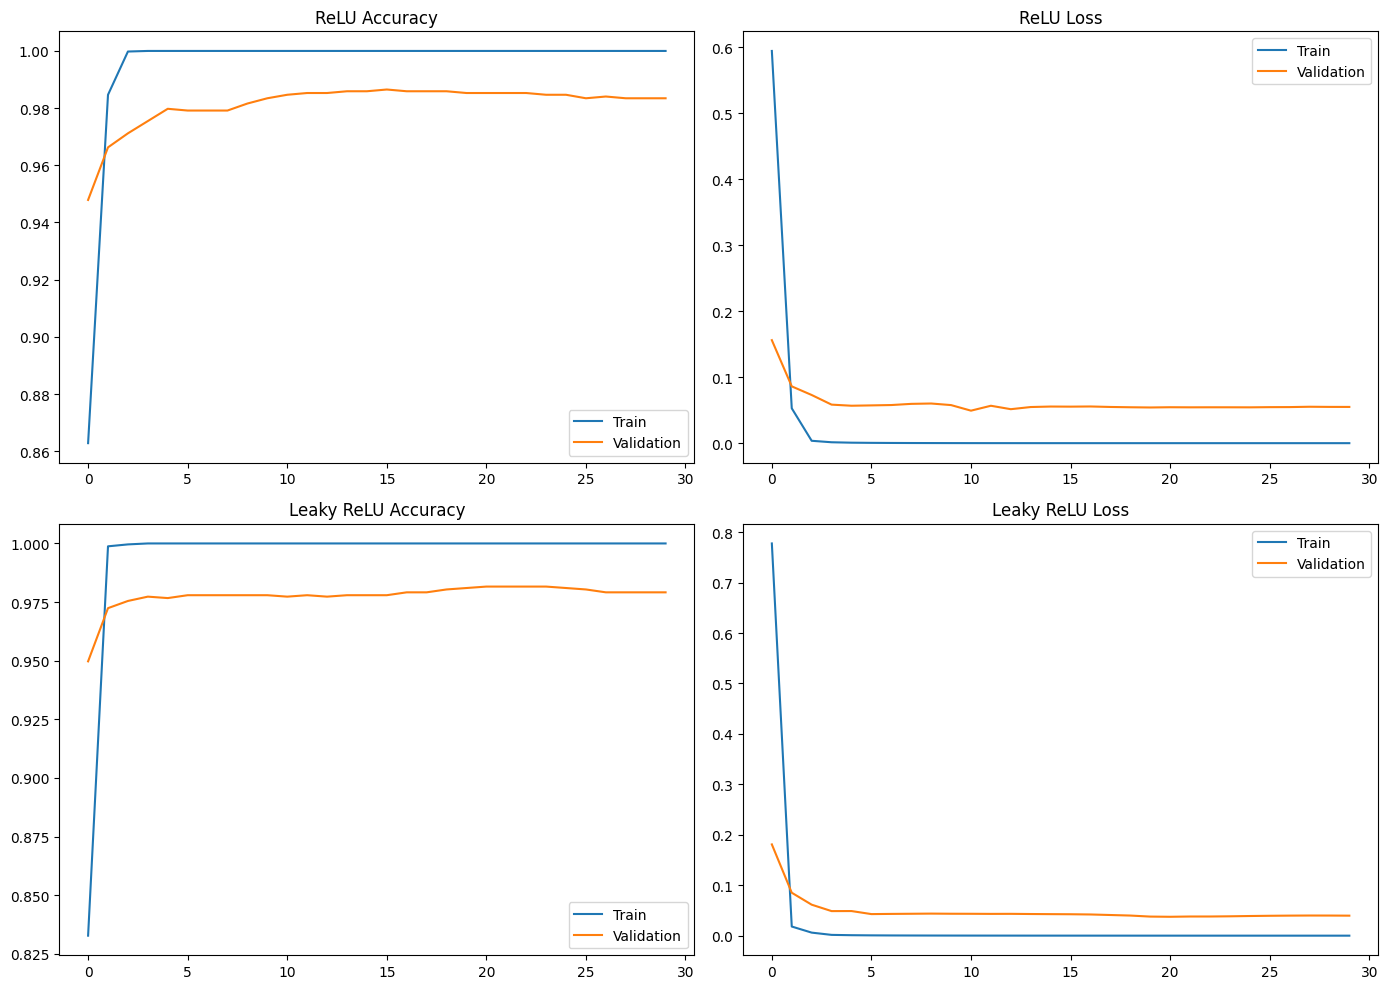

In [72]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

# ReLU Accuracy
axes[0,0].plot(
    history_relu.history['accuracy'],
    label='Train'
)

axes[0,0].plot(
    history_relu.history['val_accuracy'],
    label='Validation'
)

axes[0,0].set_title(
    'ReLU Accuracy'
)

axes[0,0].legend()

# ReLU Loss
axes[0,1].plot(
    history_relu.history['loss'],
    label='Train'
)

axes[0,1].plot(
    history_relu.history['val_loss'],
    label='Validation'
)

axes[0,1].set_title(
    'ReLU Loss'
)

axes[0,1].legend()

# Leaky Accuracy
axes[1,0].plot(
    history_leaky.history['accuracy'],
    label='Train'
)

axes[1,0].plot(
    history_leaky.history['val_accuracy'],
    label='Validation'
)

axes[1,0].set_title(
    'Leaky ReLU Accuracy'
)

axes[1,0].legend()

# Leaky Loss
axes[1,1].plot(
    history_leaky.history['loss'],
    label='Train'
)

axes[1,1].plot(
    history_leaky.history['val_loss'],
    label='Validation'
)

axes[1,1].set_title(
    'Leaky ReLU Loss'
)

axes[1,1].legend()

plt.tight_layout()
plt.show()

#CONFUSION MATRIX RELU

In [73]:
!pip install seaborn

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


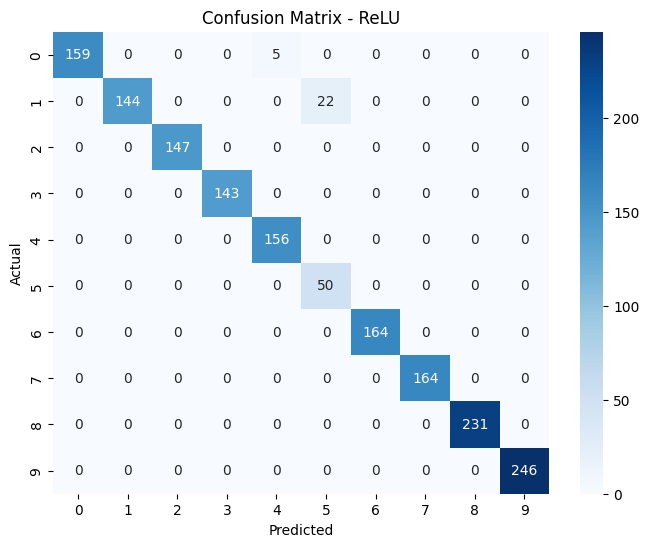

In [75]:
y_true = np.argmax(
    y_test,
    axis=1
)
y_pred_relu = np.argmax(
    relu_model.predict(x_test),
    axis=1
)
cm_relu = confusion_matrix(
    y_true,
    y_pred_relu
)
plt.figure(figsize=(8,6))

sns.heatmap(
    cm_relu,
    annot=True,
    fmt='d',
    cmap='Blues'
)
plt.title(
    'Confusion Matrix - ReLU'
)

plt.xlabel(
    'Predicted'
)
plt.ylabel(
    'Actual'
)
plt.show()

#CONFUSION MATRIX LEAKY RELU

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


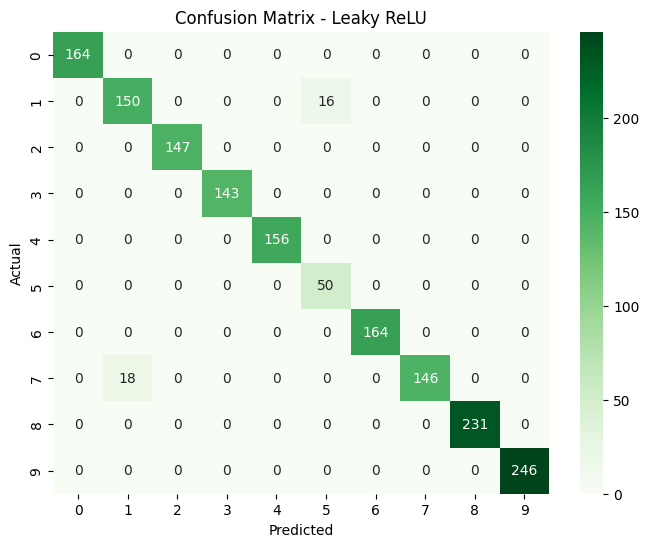

In [76]:
y_pred_leaky = np.argmax(
    leaky_model.predict(x_test),
    axis=1
)
cm_leaky = confusion_matrix(
    y_true,
    y_pred_leaky
)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm_leaky,
    annot=True,
    fmt='d',
    cmap='Greens'
)
plt.title(
    'Confusion Matrix - Leaky ReLU'
)
plt.xlabel(
    'Predicted'
)
plt.ylabel(
    'Actual'
)
plt.show()

#TEST SINGLE PREDICTION

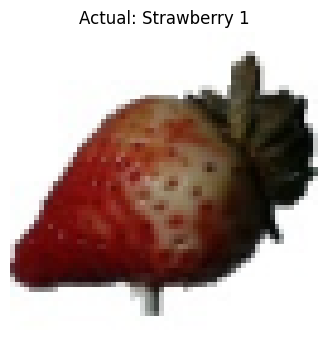

In [77]:
test_idx = np.random.randint(
    0,
    len(x_test)
)

test_img_flat = x_test[test_idx]

actual_label = np.argmax(
    y_test[test_idx]
)

plt.figure(figsize=(4,4))

plt.imshow(
    test_img_flat.reshape(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)

plt.title(
    f'Actual: {classes[actual_label]}'
)

plt.axis('off')

plt.show()

In [78]:
#PREDICTION
inp = np.expand_dims(
    test_img_flat,
    axis=0
)
relu_pred = relu_model.predict(
    inp,
    verbose=0
)
leaky_pred = leaky_model.predict(
    inp,
    verbose=0
)
relu_class = np.argmax(
    relu_pred
)
leaky_class = np.argmax(
    leaky_pred
)
print("="*50)
print(
    "TEST PREDICTION RESULT"
)
print("="*50)
print(
    f"Actual Label : {classes[actual_label]}"
)
print(
    f"ReLU Prediction : {classes[relu_class]}"
)
print(
    f"Leaky Prediction : {classes[leaky_class]}"
)

TEST PREDICTION RESULT
Actual Label : Strawberry 1
ReLU Prediction : Strawberry 1
Leaky Prediction : Strawberry 1


#PREDICTION COMPARISON TABLE

In [79]:
print(
    "\n===== PREDICTION COMPARISON =====\n"
)

print(
    f"{'No':<5}"
    f"{'Actual':<20}"
    f"{'ReLU':<20}"
    f"{'Leaky':<20}"
)

print("-"*80)

sample_idx = np.random.choice(
    len(x_test),
    20,
    replace=False
)

for idx, i in enumerate(sample_idx):

    inp = np.expand_dims(
        x_test[i],
        axis=0
    )

    actual = np.argmax(
        y_test[i]
    )

    relu_pred = np.argmax(
        relu_model.predict(
            inp,
            verbose=0
        )
    )

    leaky_pred = np.argmax(
        leaky_model.predict(
            inp,
            verbose=0
        )
    )

    print(
        f"{idx+1:<5}"
        f"{classes[actual]:<20}"
        f"{classes[relu_pred]:<20}"
        f"{classes[leaky_pred]:<20}"
    )


===== PREDICTION COMPARISON =====

No   Actual              ReLU                Leaky               
--------------------------------------------------------------------------------
1    Kiwi 1              Kiwi 1              Kiwi 1              
2    Tomato 1            Tomato 1            Tomato 1            
3    Avocado 1           Avocado 1           Avocado 1           
4    Avocado 1           Avocado 1           Avocado 1           
5    Papaya 1            Papaya 1            Papaya 1            
6    Strawberry 1        Strawberry 1        Strawberry 1        
7    Avocado 1           Avocado 1           Avocado 1           
8    Tomato 1            Tomato 1            Tomato 1            
9    Pear 10             Pear 10             Pear 10             
10   Banana 1            Banana 1            Banana 1            
11   Tomato 1            Tomato 1            Tomato 1            
12   Tomato 1            Tomato 1            Tomato 1            
13   Papaya 1            

In [80]:
print("ReLU Accuracy :", relu_acc)
print("ReLU Loss     :", relu_loss)

print("Leaky Accuracy:", leaky_acc)
print("Leaky Loss    :", leaky_loss)

ReLU Accuracy : 0.9834457635879517
ReLU Loss     : 0.054951347410678864
Leaky Accuracy: 0.9791538715362549
Leaky Loss    : 0.03967290371656418


In [81]:
#ubah logika winner berdasarkan komparasi accuracy dan loss masing2 model
if relu_acc > leaky_acc:
    winner = "ReLU"
elif leaky_acc > relu_acc:
    winner = "Leaky ReLU"
else:
    winner = (
        "ReLU"
        if relu_loss < leaky_loss
        else "Leaky ReLU"
    )

In [82]:
#tampilkan pemenang
print("="*50)
print(
    f"{'Model':<15}"
    f"{'Accuracy':>12}"
    f"{'Loss':>12}"
)
print("="*50)
print(
    f"{'ReLU':<15}"
    f"{relu_acc:>12.4f}"
    f"{relu_loss:>12.6f}"
)
print(
    f"{'Leaky ReLU':<15}"
    f"{leaky_acc:>12.4f}"
    f"{leaky_loss:>12.6f}"
)
print("="*50)
# Determine Winner
if relu_acc > leaky_acc:
    winner = "ReLU"
elif leaky_acc > relu_acc:
    winner = "Leaky ReLU"
else:
    if relu_loss < leaky_loss:
        winner = "ReLU"

    else:

        winner = "Leaky ReLU"

print(f"\n🏆 WINNER : {winner}")

Model              Accuracy        Loss
ReLU                 0.9834    0.054951
Leaky ReLU           0.9792    0.039673

🏆 WINNER : ReLU


In [83]:
print("Winner:", winner)

print(
    "fruit_best_model.keras updated successfully"
)

Winner: ReLU
fruit_best_model.keras updated successfully


In [84]:
#save model
relu_model.save_weights(
    "fruit_best_weights.weights.h5"
)

print("Weights saved!")

Weights saved!


#Conclusion

This study compared the performance of Artificial Neural Networks (ANN) using ReLU and Leaky ReLU activation functions for fruit image classification on the Fruit360 dataset. Both models were trained and evaluated using the same dataset and network architecture to ensure a fair comparison.

The experimental results showed that the ReLU model achieved an accuracy of 98.34%, while the Leaky ReLU model achieved 97.92%. Although the Leaky ReLU model produced a lower loss value (0.039673) compared to ReLU (0.054951), ReLU demonstrated better classification accuracy and was therefore selected as the best-performing model.

The developed Streamlit application successfully implemented the trained model and was able to classify fruit images with high confidence. Testing on images from the Fruit360 dataset resulted in highly accurate predictions, while some real-world images obtained from external sources produced less accurate results. This indicates that the model performs well on data with characteristics similar to the training dataset but has limited generalization capability when faced with images that differ in lighting, background, and image quality.

In conclusion, the ReLU activation function provided better overall classification performance than Leaky ReLU for the Fruit360 dataset. Future work may focus on improving model generalization through data augmentation, larger and more diverse datasets, or the implementation of Convolutional Neural Networks (CNNs) for enhanced image feature extraction.